In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error

In [19]:
df = pd.read_csv('data/StudentPerformanceFactors.csv')

In [5]:
df

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [7]:
df.isnull()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6603,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6604,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6605,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum().sum()

235

In [9]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [10]:
numeric_df = df[['Hours_Studied', 'Attendance', 'Sleep_Hours',
                  'Previous_Scores', 'Tutoring_Sessions',
                  'Physical_Activity', 'Exam_Score']]

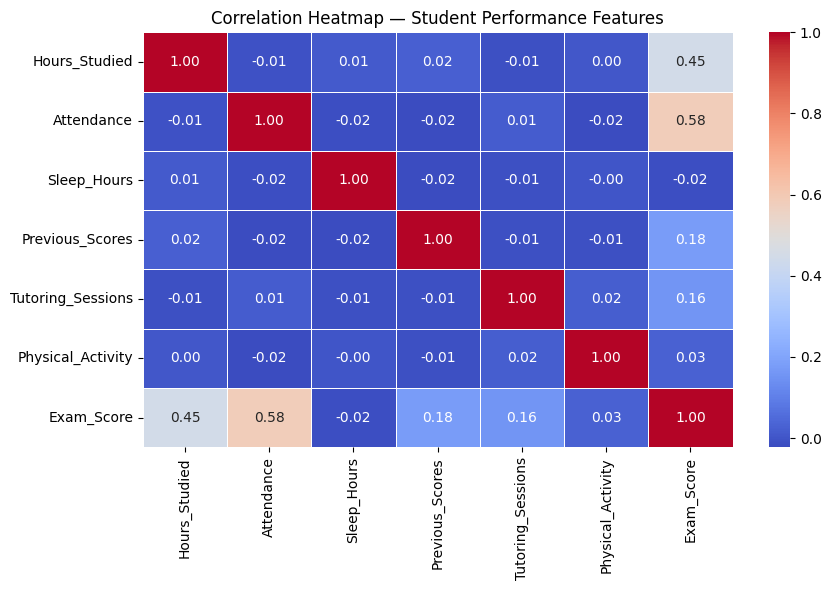

In [11]:
plt.figure(figsize=(9, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f",
            cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap — Student Performance Features")
plt.tight_layout()
plt.show()

In [12]:
x = df['Hours_Studied'].values
y = df['Exam_Score'].values

In [13]:
model   = np.polyfit(x, y, 1)
predict = np.poly1d(model)

In [14]:
print(f"\nSlope (m)     : {model[0]:.4f}")
print(f"Intercept (b) : {model[1]:.4f}")
print(f"Equation      : Exam_Score = {model[0]:.4f} * Hours_Studied + {model[1]:.4f}")



Slope (m)     : 0.2893
Intercept (b) : 61.4570
Equation      : Exam_Score = 0.2893 * Hours_Studied + 61.4570


In [15]:
y_pred = predict(x)

In [16]:
print("\nPredicted Exam Score for 30 hrs studied:", round(predict(30), 2))


Predicted Exam Score for 30 hrs studied: 70.14


In [17]:
mse  = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y, y_pred)

print(f"\n{'Metric':<10} {'Value':>10}")
print("-" * 22)
print(f"{'MSE':<10} {mse:>10.4f}")
print(f"{'RMSE':<10} {rmse:>10.4f}")
print(f"{'R² Score':<10} {r2:>10.4f}")


Metric          Value
----------------------
MSE           12.1304
RMSE           3.4829
R² Score       0.1984


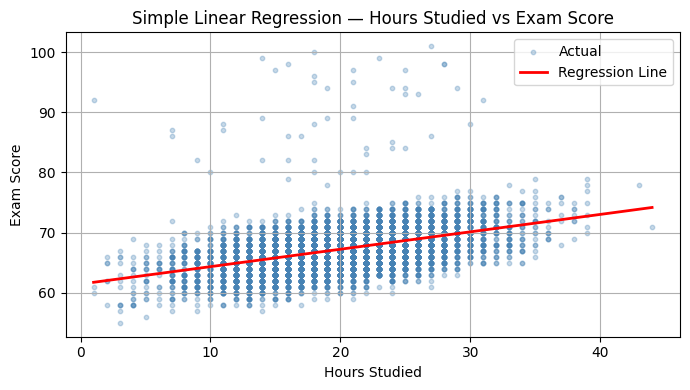

In [18]:
x_sorted = np.sort(x)
plt.figure(figsize=(7, 4))
plt.scatter(x, y, c='steelblue', alpha=0.3, s=10, label='Actual')
plt.plot(x_sorted, predict(x_sorted), c='red', linewidth=2, label='Regression Line')
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Simple Linear Regression — Hours Studied vs Exam Score")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()